# Análisis EDA y Clasificación de Tickets de Incidentes Bancarios

Este notebook realiza un análisis exploratorio de datos (EDA) y un modelo de clasificación para predecir la categoría de cada ticket de incidentes bancarios a partir de un archivo CSV.

## 1. Carga de Librerías y Configuración Inicial

In [152]:
# Importar librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize':(10,6)})

## 2. Carga y Exploración Inicial de Datos

In [153]:
# Cargar el archivo CSV
# Usa la ruta absoluta o relativa correcta según tu entorno
ruta_csv = 'Categorizaciones_incidentes_depurado(Hoja1).csv'  # Archivo está en la misma carpeta que el notebook
import os
print('Directorio actual:', os.getcwd())
print('Archivos en el directorio actual:', os.listdir())
print('Archivos en ./Data:', os.listdir('./') if os.path.exists('./') else 'No existe ./')

# Intenta cargar el archivo
try:
    df = pd.read_csv(ruta_csv, sep=',', encoding='latin-1')
except FileNotFoundError as e:
    print('No se encontró el archivo. Verifica la ruta y ubicación.')
    raise e

# Mostrar primeras filas y resumen
print('Dimensiones:', df.shape)
df.head()

Directorio actual: c:\Users\paomaribel\Documents\GitHub\Asignador\Data
Archivos en el directorio actual: ['Categorizaciones incidentes_depurado.xlsx', 'Categorizaciones_incidentes_clasificadas.csv', 'Categorizaciones_incidentes_depurado(Hoja1).csv', 'EDA_Categorizacion_Incidentes.ipynb']
Archivos en ./Data: ['Categorizaciones incidentes_depurado.xlsx', 'Categorizaciones_incidentes_clasificadas.csv', 'Categorizaciones_incidentes_depurado(Hoja1).csv', 'EDA_Categorizacion_Incidentes.ipynb']
Dimensiones: (7353, 33)


,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,cmdb_ci,...,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error,Origen,Ambiente,Clasificación,Proceso / Categoria técnica
0,INC0755414,Nuevo,19/02/2026 16:30:59,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,segun ticket ingresado RITM0800991 me sugiere...,NaN,NaN,NaN,NaN,NaN,Banco,Producción,0,0
1,INC0754016,Nuevo,18/02/2026 23:00:43,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,CON FECHA 22 DE ENERO 2026 LAS OPERACIONES 800...,NaN,NaN,NaN,NaN,NaN,Banco,Producción,Cuentas,"Error de negocio, cuenta con valores pendiente..."
2,INC0754538,Nuevo,19/02/2026 09:55:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,"Favor su apoyo, revisando el abono al capital,...",NaN,NaN,NaN,NaN,NaN,Operaciones,Producción,Activos,Diferencia en la redistibución de Bancs
3,INC0753295,Nuevo,18/02/2026 14:30:54,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,por favor su ayuda con la regularización para ...,18/02/2026 17:35:05 - JOAO CRISTOFFER PEREZ PA...,NaN,NaN,NaN,NaN,Banco,Test,No productivo,No aplica
4,INC0756601,Nuevo,20/02/2026 10:46:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,su gentil ayuda con el siguiente caso la clien...,NaN,NaN,NaN,NaN,NaN,Banco,Producción,0,0


In [154]:
# Tipos de datos y valores nulos
df.info()
df.isnull().sum().sort_values(ascending=False).head(15)

<class 'pandas.DataFrame'>
RangeIndex: 7353 entries, 0 to 7352
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   number                       7353 non-null   str  
 1   state                        7353 non-null   str  
 2   sys_created_on               7353 non-null   str  
 3   category                     7353 non-null   str  
 4   u_subcategory                7353 non-null   str  
 5   u_subcategory_2              7353 non-null   str  
 6   contact_type                 7353 non-null   str  
 7   business_duration            7353 non-null   int64
 8   cmdb_ci_business_app         4793 non-null   str  
 9   cmdb_ci                      2329 non-null   str  
 10  short_description            7353 non-null   str  
 11  priority                     7353 non-null   str  
 12  severity                     7353 non-null   str  
 13  caller_id                    7353 non-null   str  
 14  u_a

cmdb_ci                        5024
cmdb_ci_business_app           2560
comments_and_work_notes        1453
u_subcategoria_error            641
u_categoria_error               639
location.cmn_location_type      587
location                        587
Proceso / Categoria técnica     403
Ambiente                        397
Clasificación                   397
Origen                          397
u_affected_user.department      116
resolved_at                      27
close_notes                      26
assigned_to                       7
dtype: int64

In [155]:
# Exploración rápida de variables informativas
print('Resumen de columnas:')
df.info()
print('\nPrimeras filas:')
display(df.head())
print('\nPorcentaje de valores nulos por columna:')
print((df.isnull().mean()*100).sort_values(ascending=False))
print('\nNúmero de valores únicos por columna:')
print(df.nunique().sort_values(ascending=False))

# Sugerencia de variables informativas (no ID, no columnas vacías o con un solo valor)
columnas_informativas = [col for col in df.columns if df[col].nunique()>1 and df[col].nunique()<df.shape[0]*0.9 and not col.lower().startswith('id')]
print('\nColumnas potencialmente informativas:')
print(columnas_informativas)

Resumen de columnas:
<class 'pandas.DataFrame'>
RangeIndex: 7353 entries, 0 to 7352
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   number                       7353 non-null   str  
 1   state                        7353 non-null   str  
 2   sys_created_on               7353 non-null   str  
 3   category                     7353 non-null   str  
 4   u_subcategory                7353 non-null   str  
 5   u_subcategory_2              7353 non-null   str  
 6   contact_type                 7353 non-null   str  
 7   business_duration            7353 non-null   int64
 8   cmdb_ci_business_app         4793 non-null   str  
 9   cmdb_ci                      2329 non-null   str  
 10  short_description            7353 non-null   str  
 11  priority                     7353 non-null   str  
 12  severity                     7353 non-null   str  
 13  caller_id                    7353 non-

,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,cmdb_ci,...,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error,Origen,Ambiente,Clasificación,Proceso / Categoria técnica
0,INC0755414,Nuevo,19/02/2026 16:30:59,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,segun ticket ingresado RITM0800991 me sugiere...,NaN,NaN,NaN,NaN,NaN,Banco,Producción,0,0
1,INC0754016,Nuevo,18/02/2026 23:00:43,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,CON FECHA 22 DE ENERO 2026 LAS OPERACIONES 800...,NaN,NaN,NaN,NaN,NaN,Banco,Producción,Cuentas,"Error de negocio, cuenta con valores pendiente..."
2,INC0754538,Nuevo,19/02/2026 09:55:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,"Favor su apoyo, revisando el abono al capital,...",NaN,NaN,NaN,NaN,NaN,Operaciones,Producción,Activos,Diferencia en la redistibución de Bancs
3,INC0753295,Nuevo,18/02/2026 14:30:54,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,por favor su ayuda con la regularización para ...,18/02/2026 17:35:05 - JOAO CRISTOFFER PEREZ PA...,NaN,NaN,NaN,NaN,Banco,Test,No productivo,No aplica
4,INC0756601,Nuevo,20/02/2026 10:46:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,su gentil ayuda con el siguiente caso la clien...,NaN,NaN,NaN,NaN,NaN,Banco,Producción,0,0



Porcentaje de valores nulos por columna:
cmdb_ci                        68.325853
cmdb_ci_business_app           34.815721
comments_and_work_notes        19.760642
u_subcategoria_error            8.717530
u_categoria_error               8.690330
location.cmn_location_type      7.983136
location                        7.983136
Proceso / Categoria técnica     5.480756
Ambiente                        5.399157
Clasificación                   5.399157
Origen                          5.399157
u_affected_user.department      1.577587
resolved_at                     0.367197
close_notes                     0.353597
assigned_to                     0.095199
description                     0.067999
u_affected_user                 0.040800
u_affected_user.title           0.040800
u_affected_user.company         0.040800
number                          0.000000
priority                        0.000000
caller_id                       0.000000
short_description               0.000000
contact_type   

## 3. Limpieza y Preprocesamiento de Datos

## 3.1 Columna Clasificación

In [156]:
# Mostrar las primeras filas del archivo CSV para conocer la estructura
display(df.head())

,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,cmdb_ci,...,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error,Origen,Ambiente,Clasificación,Proceso / Categoria técnica
0,INC0755414,Nuevo,19/02/2026 16:30:59,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,segun ticket ingresado RITM0800991 me sugiere...,NaN,NaN,NaN,NaN,NaN,Banco,Producción,0,0
1,INC0754016,Nuevo,18/02/2026 23:00:43,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,CON FECHA 22 DE ENERO 2026 LAS OPERACIONES 800...,NaN,NaN,NaN,NaN,NaN,Banco,Producción,Cuentas,"Error de negocio, cuenta con valores pendiente..."
2,INC0754538,Nuevo,19/02/2026 09:55:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,"Favor su apoyo, revisando el abono al capital,...",NaN,NaN,NaN,NaN,NaN,Operaciones,Producción,Activos,Diferencia en la redistibución de Bancs
3,INC0753295,Nuevo,18/02/2026 14:30:54,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0,Bancs,NaN,...,por favor su ayuda con la regularización para ...,18/02/2026 17:35:05 - JOAO CRISTOFFER PEREZ PA...,NaN,NaN,NaN,NaN,Banco,Test,No productivo,No aplica
4,INC0756601,Nuevo,20/02/2026 10:46:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0,Bancs,NaN,...,su gentil ayuda con el siguiente caso la clien...,NaN,NaN,NaN,NaN,NaN,Banco,Producción,0,0


In [157]:
# Revisar valores únicos y nulos en 'Clasificación'
if 'Clasificación' in df.columns:
    print('Valores únicos en Clasificación:', df['Clasificación'].unique())
    print('Valores nulos en Clasificación:', df['Clasificación'].isnull().sum())
else:
    print("La columna 'Clasificación' no está presente en el DataFrame.")

Valores únicos en Clasificación: <StringArray>
[                     '0',                'Cuentas',                'Activos',
          'No productivo',           'Contabilidad',              'Bancslink',
              'Garantías',            'Inversiones',              'Chequeras',
              'Pendiente',              'BancsLink',       'Formas numeradas',
              'Garantias',                 'SISREP',                'Cheques',
                 'Cheque',                    'ATS',            'Incidencias',
               'Clientes',      'Estados de Cuenta',       'Formas Numeradas',
                      nan,     'Firmas Autorizadas',                  'Bancs',
         'Reportes Batch',         'Reporte Online', 'Retenciones Judiciales',
              'No aplica',               'Cuentas ',   'CC-Cancelación batch',
               'Créditos',     'Firmas autorizadas',             'Sobregiros',
                'Cartola',                 'Riesgo',                  'Giros',
     

In [158]:
# Normalización de valores en la columna 'Clasificación'
import unicodedata
import re

def normalizar_texto(texto):
    if pd.isnull(texto):
        return "sin_clasificar"
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'\\s+', ' ', texto)
    texto = texto.replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')
    texto = texto.replace('ñ', 'n')
    texto = texto.replace('.', '')
    texto = texto.replace('/', '-')
    texto = texto.replace('  ', ' ')
    return texto

df['Clasificación'] = df['Clasificación'].apply(normalizar_texto)

# Verifica los valores únicos después de la normalización
print(df['Clasificación'].unique())

<StringArray>
[                     '0',                'cuentas',                'activos',
          'no productivo',           'contabilidad',              'bancslink',
              'garantias',            'inversiones',              'chequeras',
              'pendiente',       'formas numeradas',                 'sisrep',
                'cheques',                 'cheque',                    'ats',
            'incidencias',               'clientes',      'estados de cuenta',
         'sin_clasificar',     'firmas autorizadas',                  'bancs',
         'reportes batch',         'reporte online', 'retenciones judiciales',
              'no aplica',   'cc-cancelacion batch',               'creditos',
             'sobregiros',                'cartola',                 'riesgo',
                  'giros',           'pago directo',                   'cnbs',
               'procesos',                  'mt940',        'reportes online',
               'usuarios',            

In [159]:
# 1. Agrupar valores en plural y singular en la columna 'Clasificación'
agrupaciones_plural = {
    'cheques': 'cheque',
    'cuentas': 'cuenta',
    'activos': 'activo',
    'garantias': 'garantia',
    'inversiones': 'inversion',
    'sobregiros': 'sobregiro',
    'usuarios': 'usuario',
    'procesos': 'proceso',
    'clientes': 'cliente',
    'reportes online': 'reporte online',
    'reportes batch': 'reporte batch',
    'formas numeradas': 'forma numerada',
    # Agregar más se detectan otros casos
}
df['Clasificación'] = df['Clasificación'].replace(agrupaciones_plural)

In [160]:
# Reemplazar '0', nan y 'no aplica' por 'sin_clasificar'
df['Clasificación'] = df['Clasificación'].replace(['0', 0, None, np.nan, 'no aplica'], 'sin_clasificar')

In [161]:
# 3. Asignar 'mt940' a 'forma numerada'
df['Clasificación'] = df['Clasificación'].replace('mt940', 'forma numerada')

In [162]:
# Mostrar valores únicos tras la limpieza y agrupación
print(df['Clasificación'].unique())

<StringArray>
[        'sin_clasificar',                 'cuenta',                 'activo',
          'no productivo',           'contabilidad',              'bancslink',
               'garantia',              'inversion',              'chequeras',
              'pendiente',         'forma numerada',                 'sisrep',
                 'cheque',                    'ats',            'incidencias',
                'cliente',      'estados de cuenta',     'firmas autorizadas',
                  'bancs',          'reporte batch',         'reporte online',
 'retenciones judiciales',   'cc-cancelacion batch',               'creditos',
              'sobregiro',                'cartola',                 'riesgo',
                  'giros',           'pago directo',                   'cnbs',
                'proceso',                'usuario',            'tricklefeed',
   'certificado bancario',             'co-titular',       'cc-evento-alerta',
                 'bizagi']
Length: 37,

In [163]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(conteo_clases)

Clasificación
sin_clasificar            3834
bancslink                  704
activo                     518
cuenta                     437
pendiente                  366
inversion                  360
contabilidad               209
forma numerada             177
chequeras                  151
cheque                     148
sisrep                     130
cliente                     59
estados de cuenta           48
garantia                    43
retenciones judiciales      39
firmas autorizadas          37
no productivo               35
reporte batch                9
bancs                        7
riesgo                       6
ats                          5
cnbs                         5
cc-evento-alerta             4
reporte online               3
cc-cancelacion batch         3
proceso                      3
incidencias                  2
certificado bancario         2
creditos                     1
sobregiro                    1
cartola                      1
giros                    

In [164]:
# Verificar duplicados en el DataFrame
duplicados = df[df.duplicated()]
print(f"Número de filas duplicadas: {duplicados.shape[0]}")
if not duplicados.empty:
    display(duplicados.head())
else:
    print("No se encontraron filas duplicadas.")

Número de filas duplicadas: 0
No se encontraron filas duplicadas.


## 4. Análisis Exploratorio de Datos (EDA)


--- severity ---


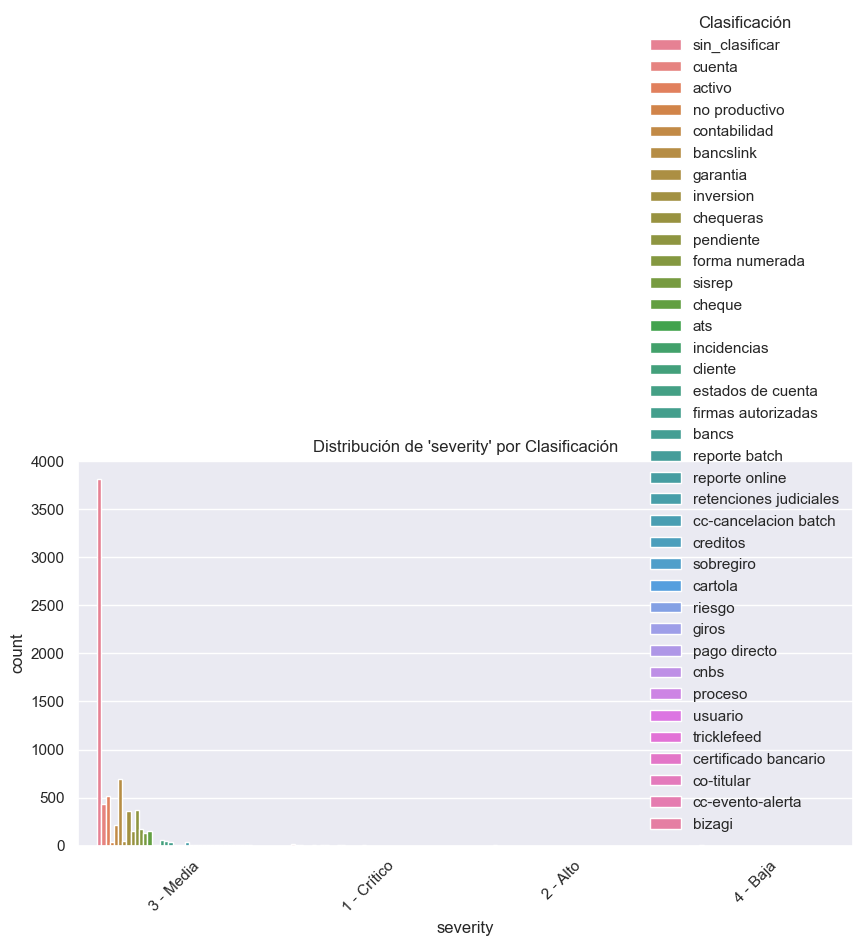

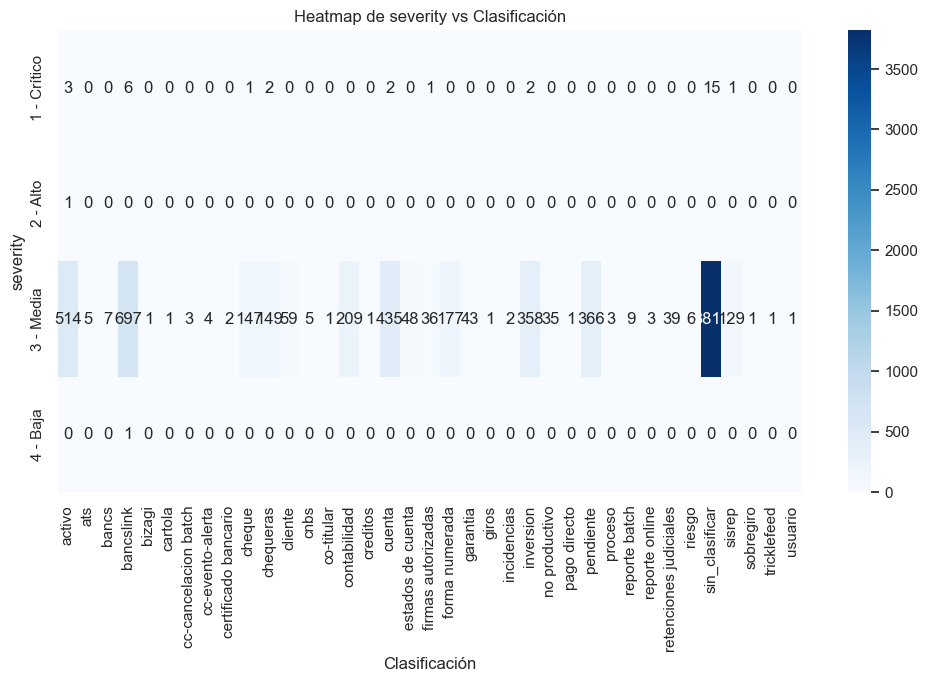


--- contact_type ---


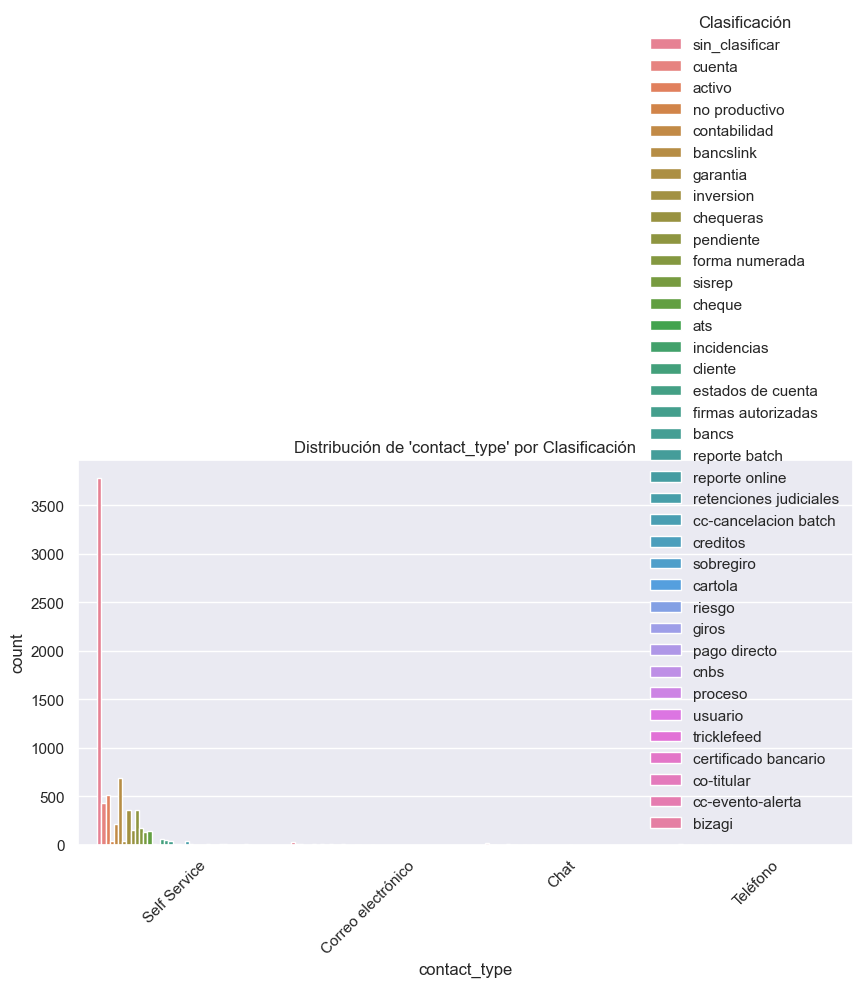

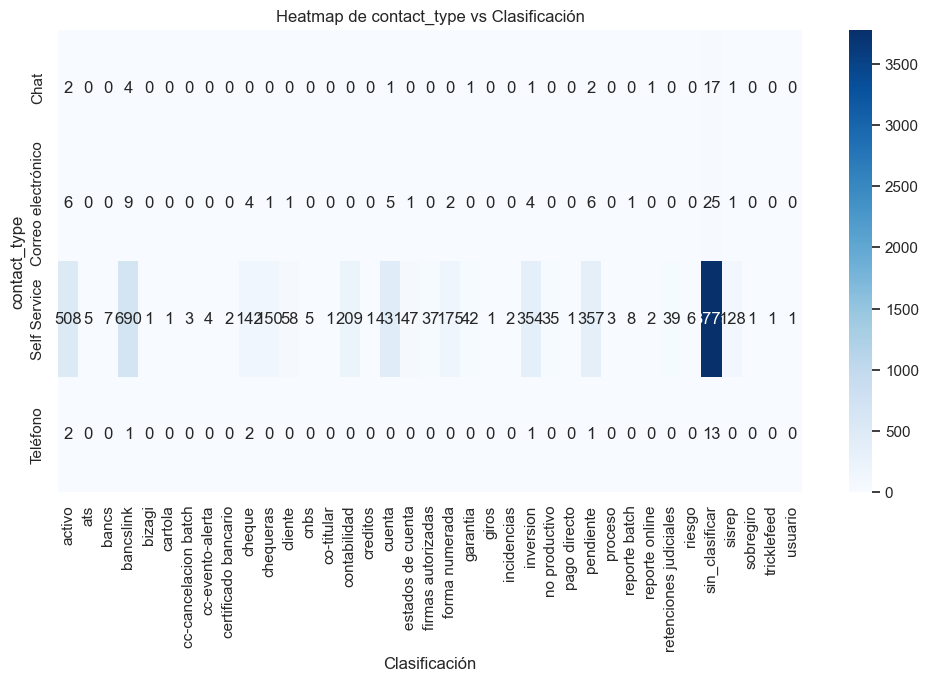


--- assignment_group ---


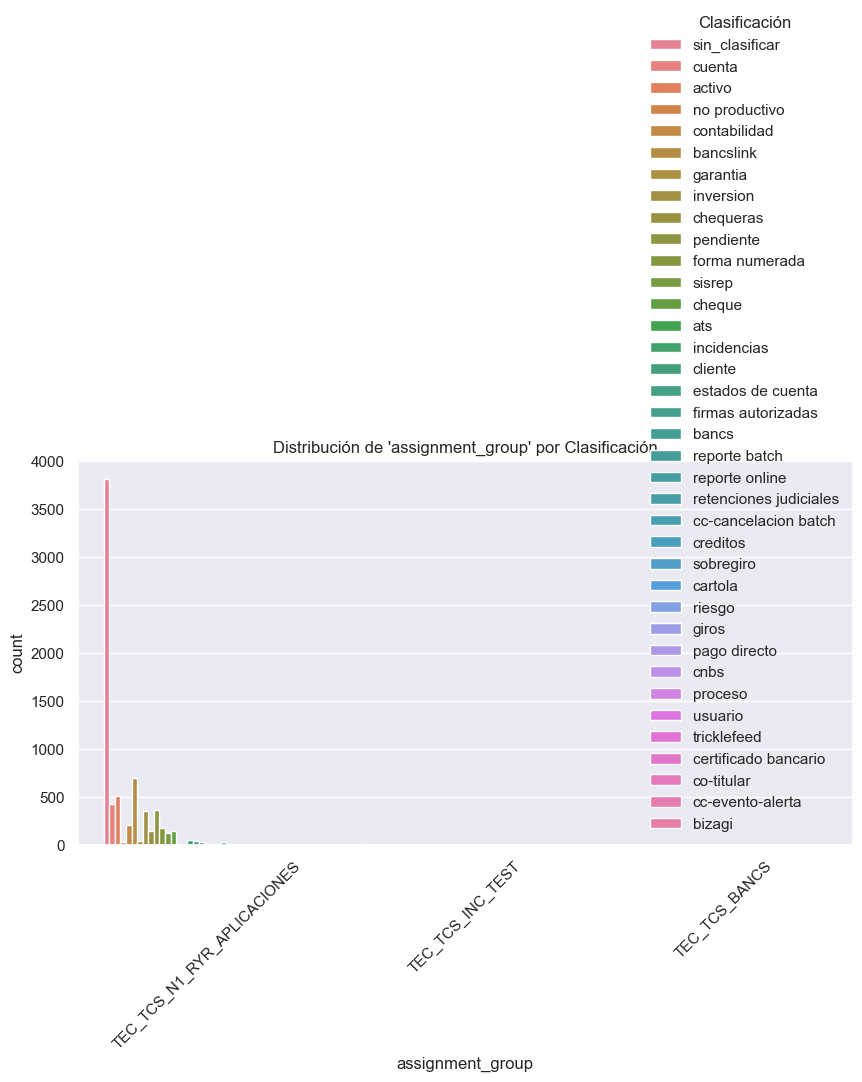

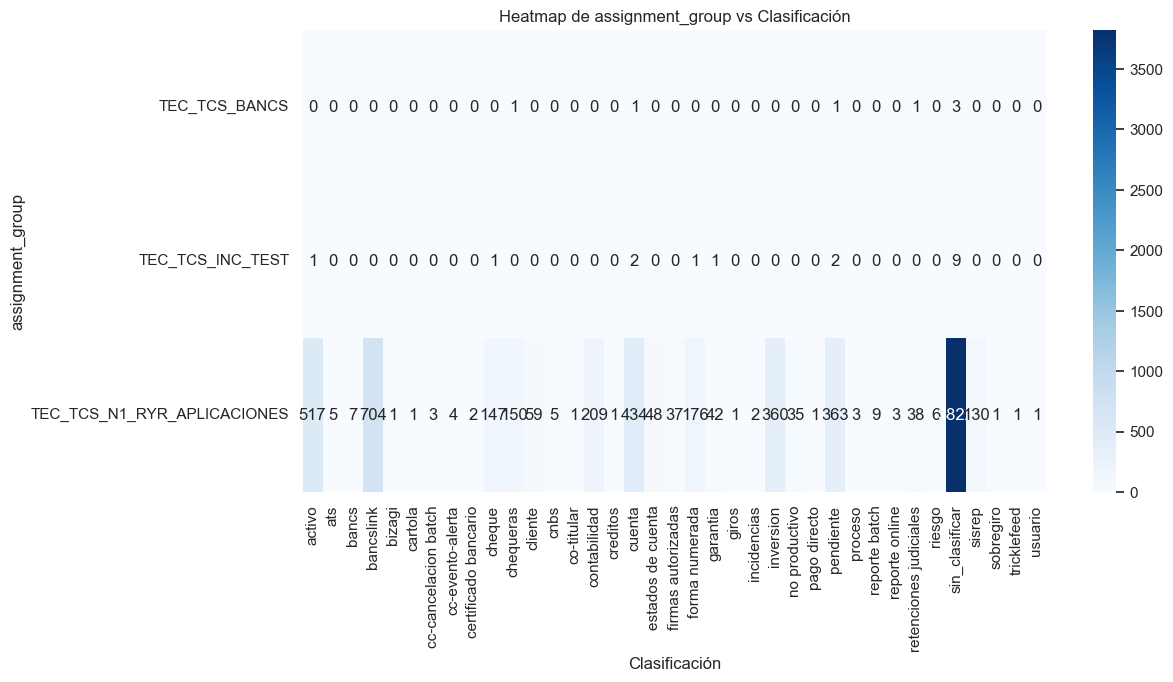


--- Origen ---


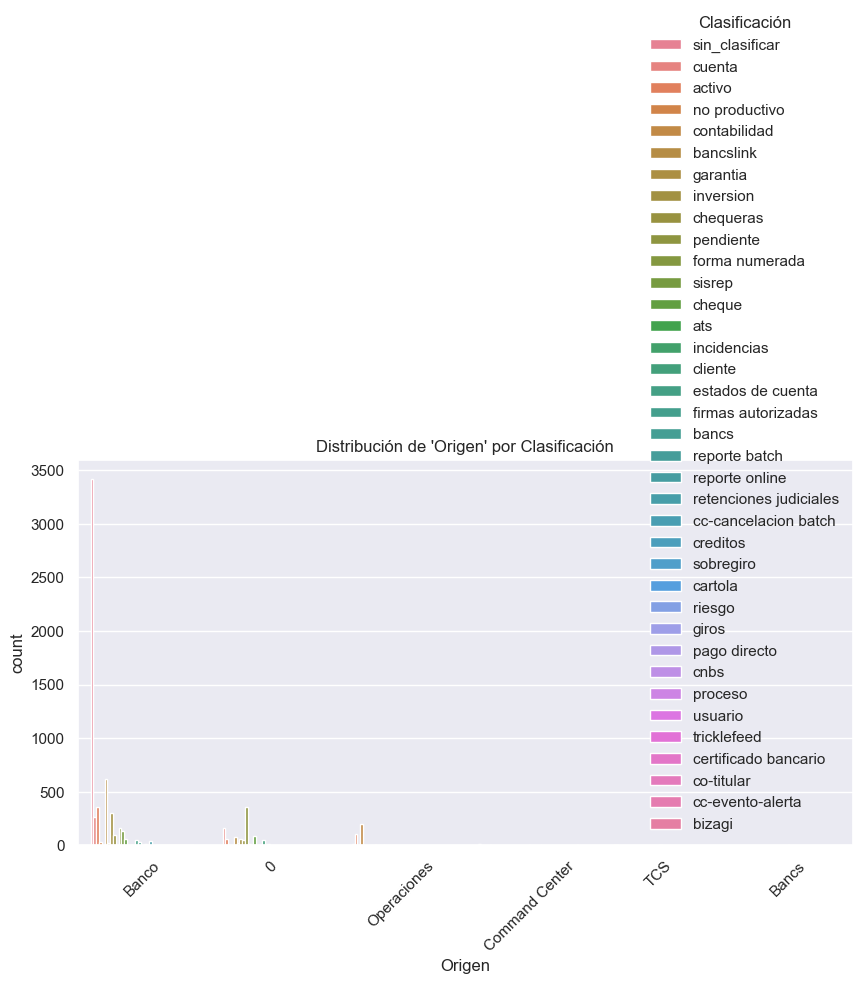

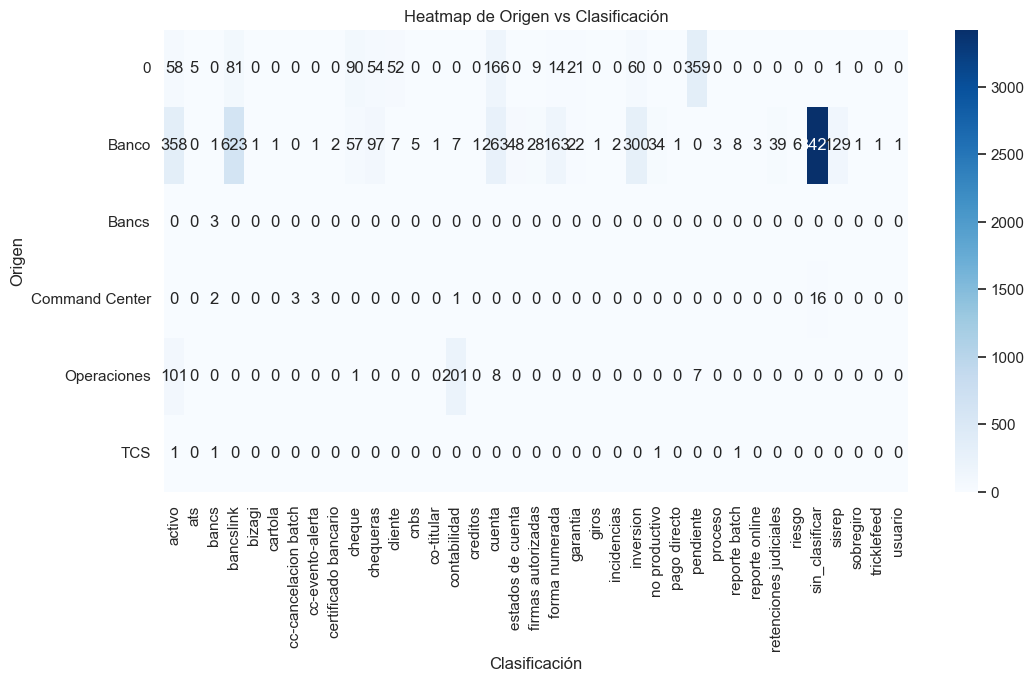


--- Ambiente ---


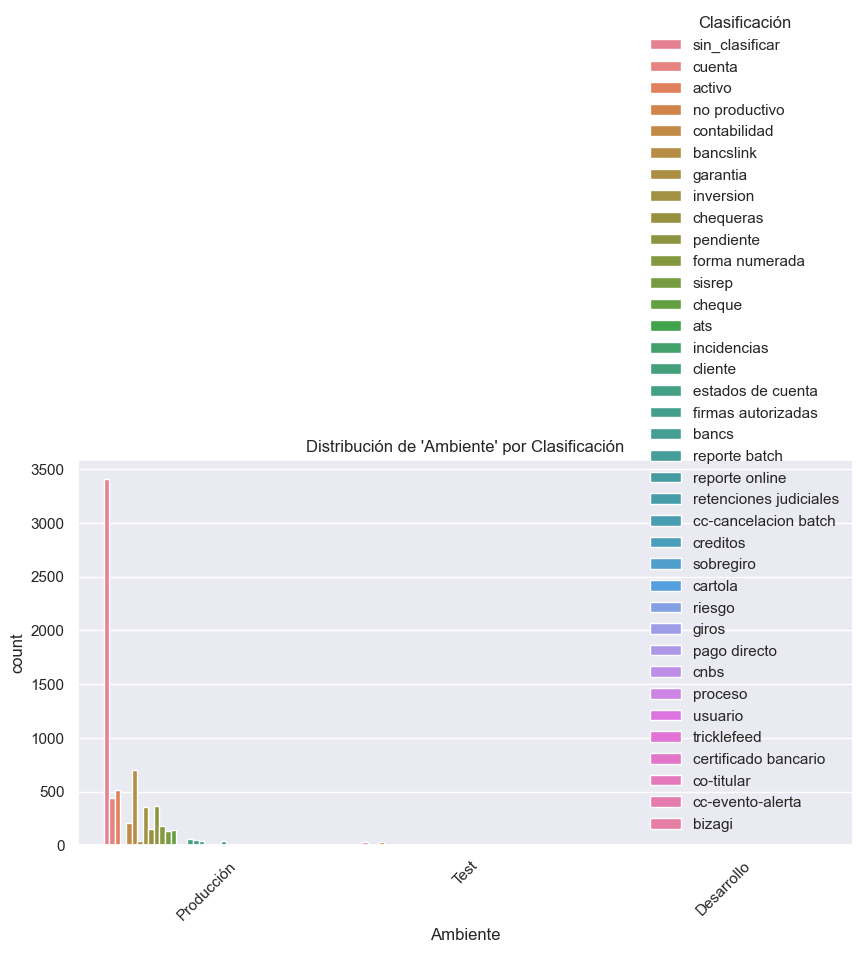

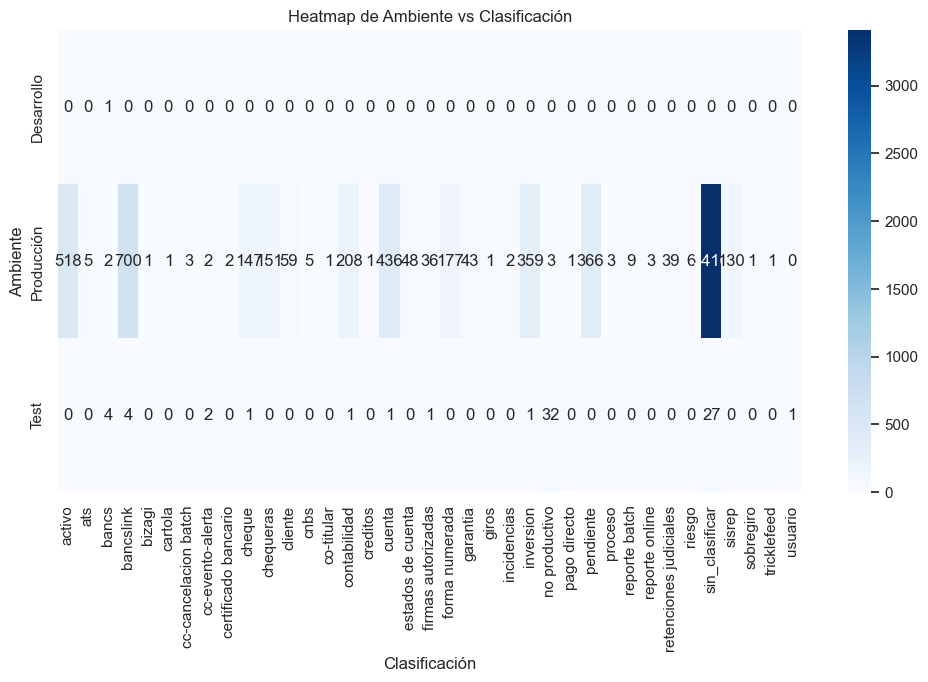


--- u_subcategory ---


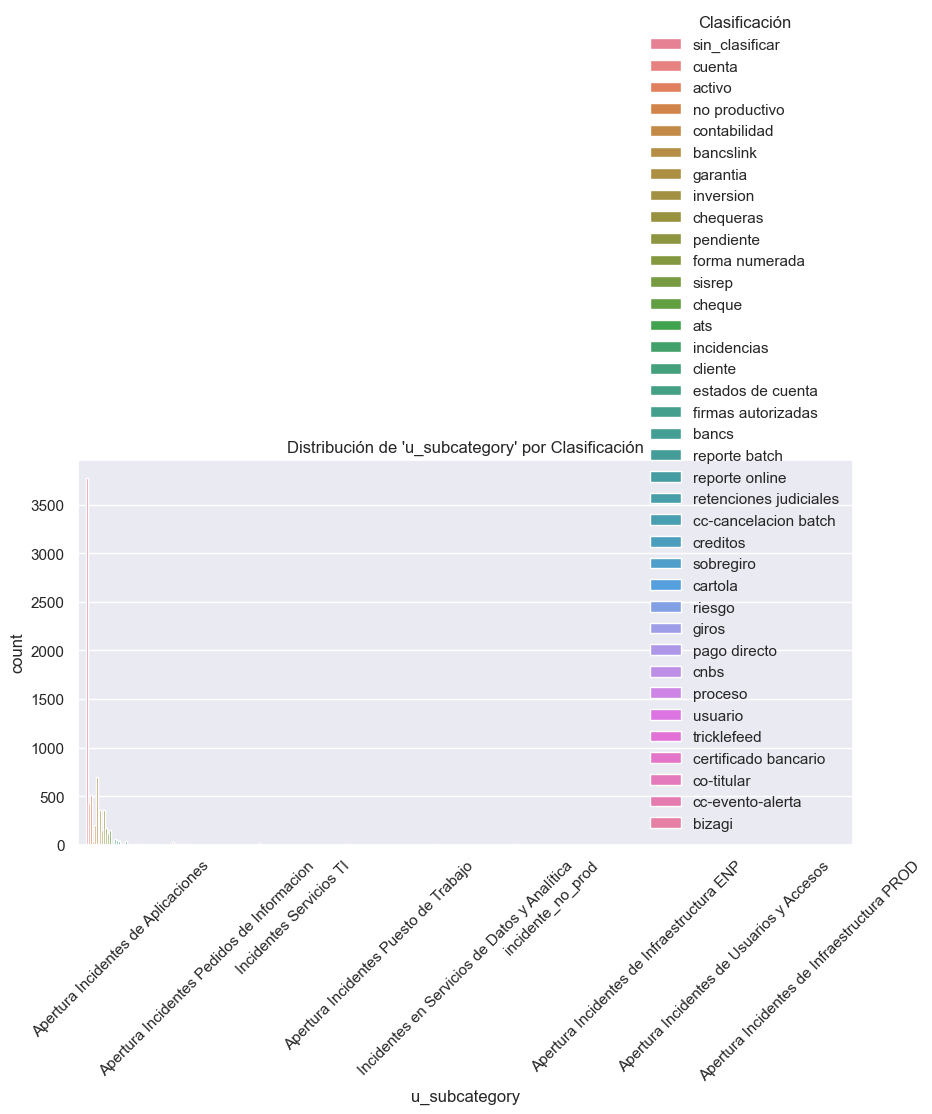

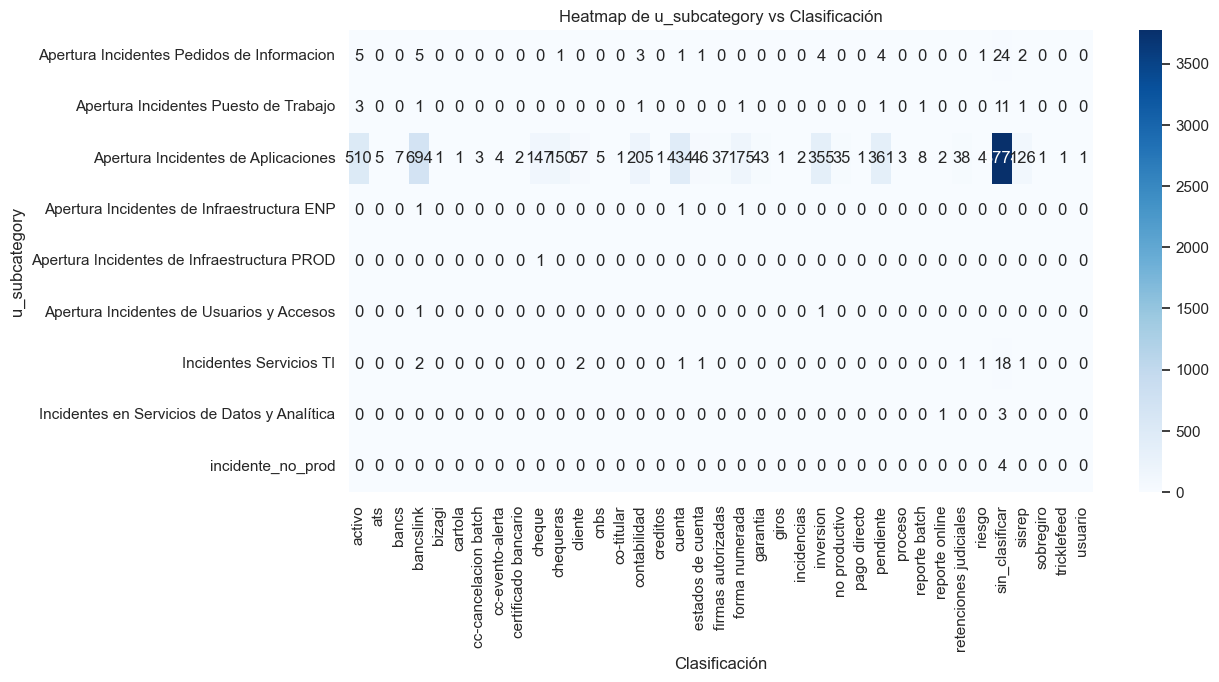


--- u_subcategory_2 ---


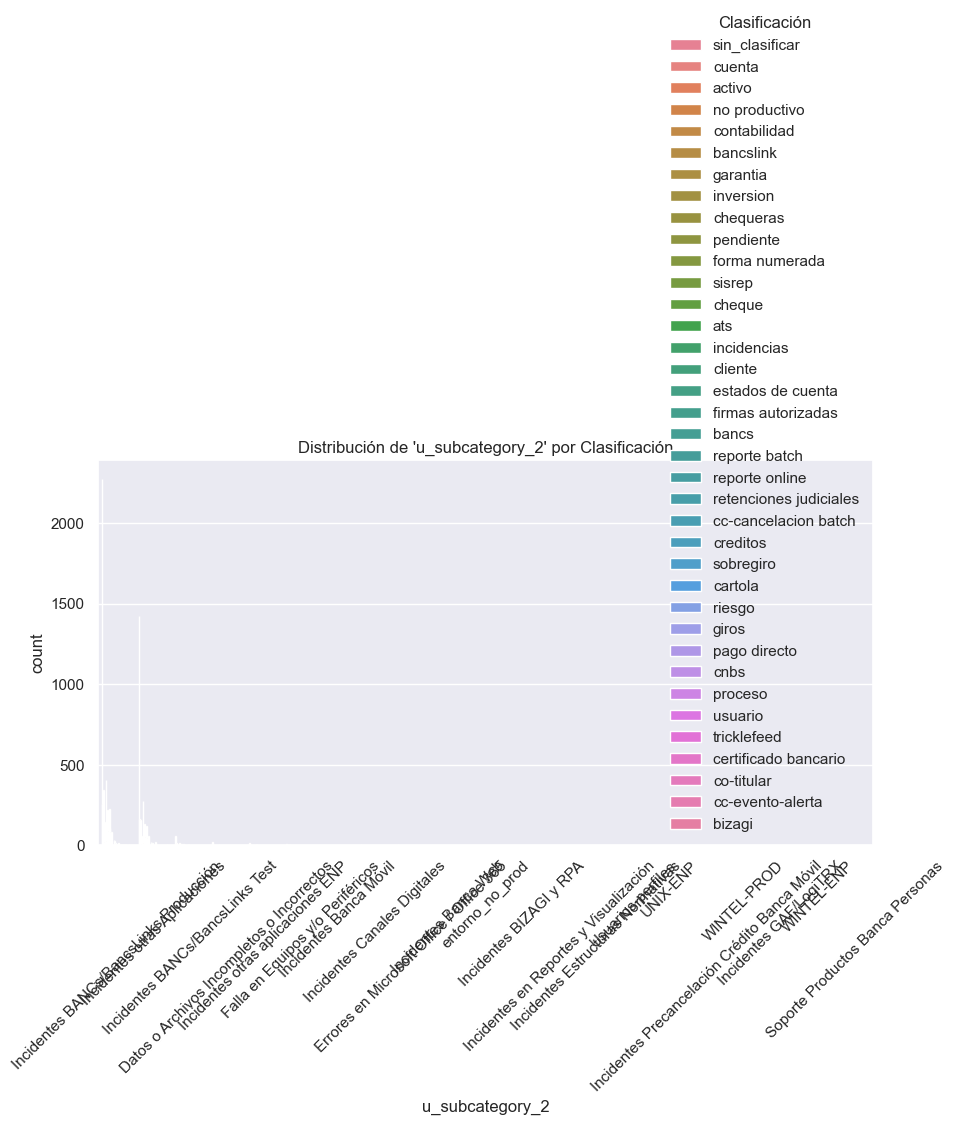

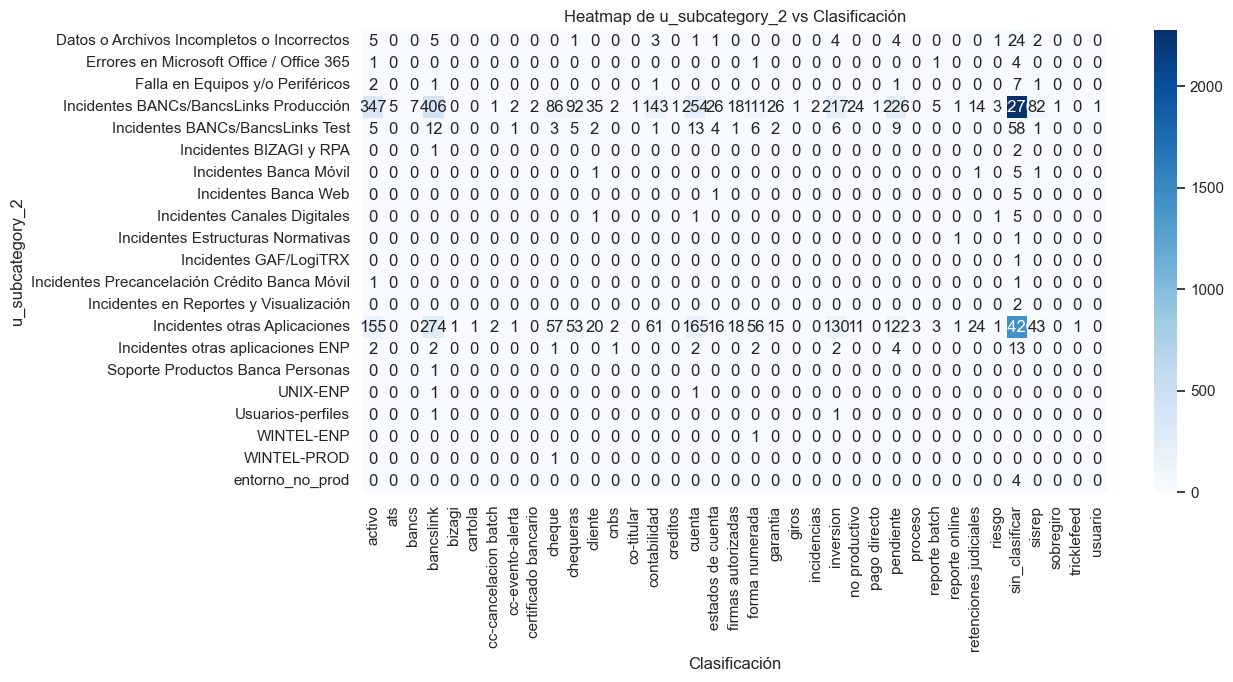

In [165]:
# Gráficos de barras apiladas y heatmaps para columnas categóricas relevantes
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

columnas_categoricas = [
    'priority', 'severity', 'contact_type', 'assignment_group', 'Origen', 'Ambiente',
    'u_subcategory', 'u_subcategory_2'
]

for col in columnas_categoricas:
    if col in df.columns and df[col].nunique() > 1 and df[col].nunique() < 25:
        print(f"\n--- {col} ---")
        # Gráfico de barras apiladas
        plt.figure(figsize=(10,5))
        sns.countplot(data=df, x=col, hue='Clasificación', order=df[col].value_counts().index)
        plt.title(f"Distribución de '{col}' por Clasificación")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        # Heatmap de la tabla de contingencia
        tabla = pd.crosstab(df[col], df['Clasificación'])
        plt.figure(figsize=(12,6))
        sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Heatmap de {col} vs Clasificación")
        plt.show()


Boxplot y ANOVA: business_duration vs Clasificación


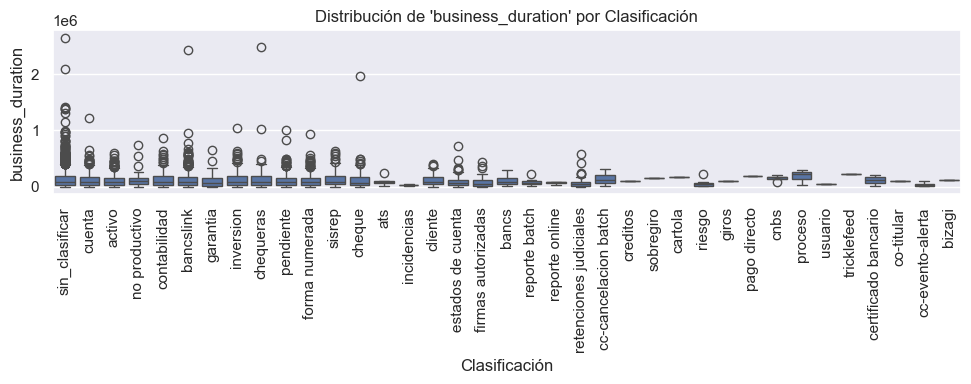

p-valor ANOVA: 0.2137

Boxplot y ANOVA: reopen_count vs Clasificación


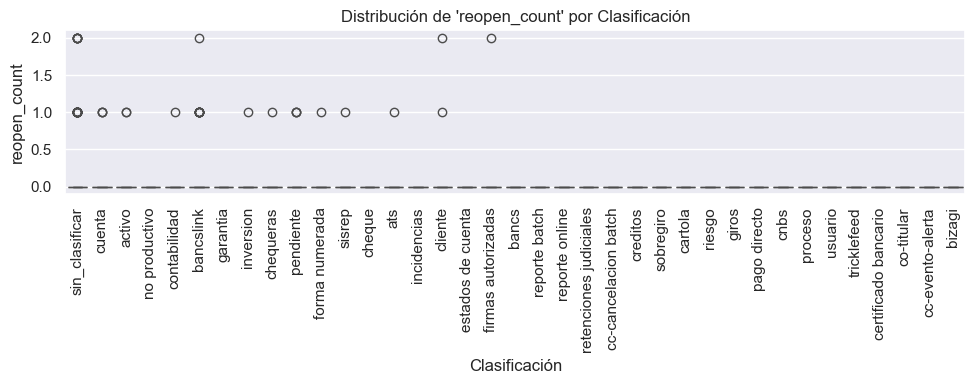

p-valor ANOVA: 0.0476


In [166]:
# 2. Variables numéricas vs. Clasificación (ANOVA y boxplots)
num_vars = [col for col in columnas_informativas if df[col].dtype in ['int64', 'float64']]
for col in num_vars:
    print(f"\nBoxplot y ANOVA: {col} vs Clasificación")
    plt.figure(figsize=(10,4))
    sns.boxplot(data=df, x='Clasificación', y=col)
    plt.title(f"Distribución de '{col}' por Clasificación")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    # ANOVA solo si hay más de un grupo
    grupos = [g[1] for g in df.groupby('Clasificación')[col] if len(g[1]) > 1]
    if len(grupos) > 1:
        stat, p = f_oneway(*grupos)
        print(f"p-valor ANOVA: {p:.4f}")

## 5. Preparación de Datos para Modelado

In [167]:
# Unificar texto relevante para análisis de similitud
df['texto_unificado'] = (
    df['short_description'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['u_subcategory'].fillna('') + ' ' +
    df['u_subcategory_2'].fillna('')
)

In [168]:
def limpiar_texto(texto):
    if pd.isnull(texto):
        return ""
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'[^a-zA-Z0-9\\s]', ' ', texto)  # Solo letras, números y espacios
    texto = re.sub(r'\\s+', ' ', texto).strip()
    return texto

df['texto_unificado'] = df['texto_unificado'].apply(limpiar_texto)
df['texto_unificado'] 

0       segun ticket ritm0800991  sugiere ingresar el ...
1       con fecha 22 de enero 2026 las operaciones 800...
2       favor su apoyo  revisando el abono al capital ...
3       repago invalido  por favor su ayuda con la reg...
4       su gentil ayuda con el siguiente caso la clien...
                              ...                        
7348    error bancs error al ingresar a bancs del usua...
7349    error en bank links error en banksnlink  en lo...
7350    error de cobro cliente 0605206614 estimados  f...
7351    seguir el flujo de la inc0020554 su ayuda con ...
7352    cancelacion  de cuanta y el documento para cie...
Name: texto_unificado, Length: 7353, dtype: str

In [169]:
# Separar tickets clasificados y no clasificados
df_clasificados = df[df['Clasificación'] != 'sin_clasificar'].copy()
df_no_clasificados = df[df['Clasificación'] == 'sin_clasificar'].copy()
print(f"Tickets clasificados: {df_clasificados.shape[0]}")
print(f"Tickets sin clasificar: {df_no_clasificados.shape[0]}")

Tickets clasificados: 3519
Tickets sin clasificar: 3834


In [170]:
# Importar nltk y descargar stopwords en español
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
spanish_stopwords = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\paomaribel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [171]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier


# Vectorizar textos (usa el mismo vectorizer que para los no clasificados)
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words=spanish_stopwords)
X_clasificados = vectorizer.fit_transform(df_clasificados['texto_unificado'])
X_no_clasificados = vectorizer.transform(df_no_clasificados['texto_unificado'])
y = df_clasificados['Clasificación']

print("Distribución original de clases:", Counter(y))


Distribución original de clases: Counter({'bancslink': 704, 'activo': 518, 'cuenta': 437, 'pendiente': 366, 'inversion': 360, 'contabilidad': 209, 'forma numerada': 177, 'chequeras': 151, 'cheque': 148, 'sisrep': 130, 'cliente': 59, 'estados de cuenta': 48, 'garantia': 43, 'retenciones judiciales': 39, 'firmas autorizadas': 37, 'no productivo': 35, 'reporte batch': 9, 'bancs': 7, 'riesgo': 6, 'ats': 5, 'cnbs': 5, 'cc-evento-alerta': 4, 'reporte online': 3, 'cc-cancelacion batch': 3, 'proceso': 3, 'incidencias': 2, 'certificado bancario': 2, 'creditos': 1, 'sobregiro': 1, 'cartola': 1, 'giros': 1, 'pago directo': 1, 'usuario': 1, 'tricklefeed': 1, 'co-titular': 1, 'bizagi': 1})


In [172]:
# Balancear clases con oversampling
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_clasificados, y)

print("Distribución balanceada de clases:", Counter(y_res))


Distribución balanceada de clases: Counter({'cuenta': 704, 'activo': 704, 'no productivo': 704, 'contabilidad': 704, 'bancslink': 704, 'garantia': 704, 'inversion': 704, 'chequeras': 704, 'pendiente': 704, 'forma numerada': 704, 'sisrep': 704, 'cheque': 704, 'ats': 704, 'incidencias': 704, 'cliente': 704, 'estados de cuenta': 704, 'firmas autorizadas': 704, 'bancs': 704, 'reporte batch': 704, 'reporte online': 704, 'retenciones judiciales': 704, 'cc-cancelacion batch': 704, 'creditos': 704, 'sobregiro': 704, 'cartola': 704, 'riesgo': 704, 'giros': 704, 'pago directo': 704, 'cnbs': 704, 'proceso': 704, 'usuario': 704, 'tricklefeed': 704, 'certificado bancario': 704, 'co-titular': 704, 'cc-evento-alerta': 704, 'bizagi': 704})


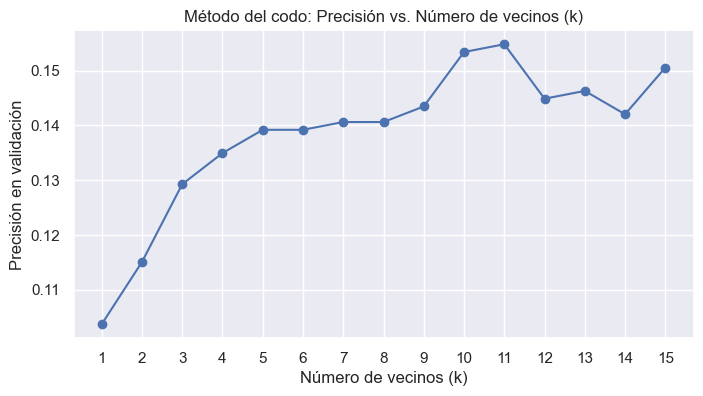

In [173]:
# Método del codo para elegir el mejor valor de k en KNN
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Usaremos una pequeña validación cruzada sobre los datos clasificados
X = vectorizer.fit_transform(df_clasificados['texto_unificado'])
y = df_clasificados['Clasificación']

k_range = range(1, 16)
precisiones = []

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)
    precision = accuracy_score(y_val, y_pred)
    precisiones.append(precision)

plt.figure(figsize=(8,4))
plt.plot(k_range, precisiones, marker='o')
plt.title('Método del codo: Precisión vs. Número de vecinos (k)')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión en validación')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [174]:
# Entrenar KNN final con k óptimo y clasificar tickets no clasificados
from sklearn.neighbors import KNeighborsClassifier

# Entrenamos el modelo con todos los tickets clasificados
k_optimo = 5
knn_final = KNeighborsClassifier(n_neighbors=k_optimo, metric='cosine')
knn_final.fit(X_res, y_res)

# Clasificar los tickets no clasificados
y_pred_no_clasificados = knn_final.predict(X_no_clasificados)
df_no_clasificados['Clasificación_predicha'] = y_pred_no_clasificados

# Mostrar ejemplos
print('Ejemplos de tickets no clasificados y su predicción:')
display(df_no_clasificados[['texto_unificado', 'Clasificación_predicha']].head())

Ejemplos de tickets no clasificados y su predicción:


,texto_unificado,Clasificación_predicha
0,segun ticket ritm0800991 sugiere ingresar el ...,sisrep
4,su gentil ayuda con el siguiente caso la clien...,sisrep
8,error descarga estados de cuenta nombres del c...,pendiente
9,no coinciden valores por pago de credito su ay...,inversion
13,error dos inversiones sin devolucion total est...,forma numerada


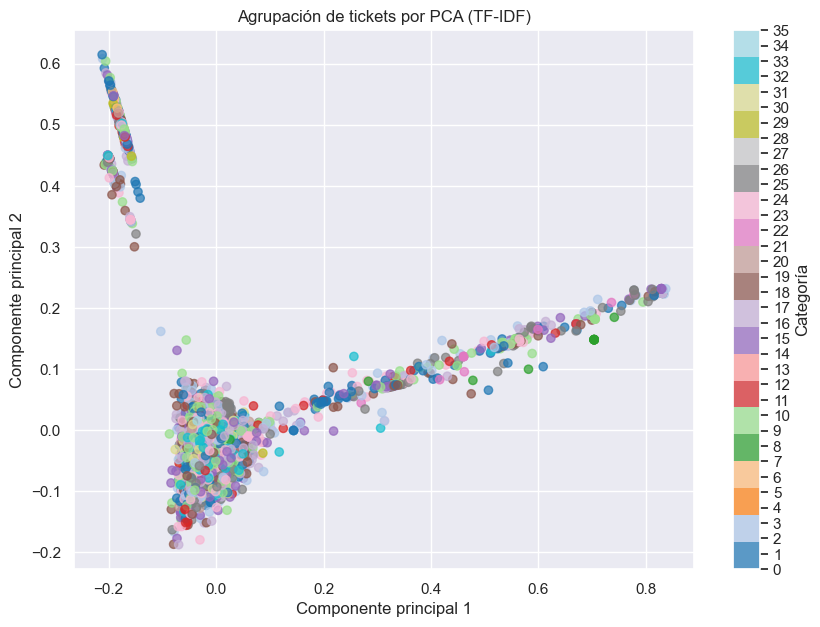

In [175]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Unir tickets clasificados y no clasificados, asignando la columna de categoría final
df_predichos = df_no_clasificados.copy()
df_predichos['Clasificación_final'] = df_predichos['Clasificación_predicha']
df_clasificados['Clasificación_final'] = df_clasificados['Clasificación']

df_pca = pd.concat([df_clasificados, df_predichos], ignore_index=True)

# Vectorizar el texto
tfidf = TfidfVectorizer(stop_words=spanish_stopwords)
X_tfidf = tfidf.fit_transform(df_pca['texto_unificado'])

# Reducir a 2 dimensiones con PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

# Graficar
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_pca['Clasificación_final'].astype('category').cat.codes,
    cmap='tab20', alpha=0.7
)
plt.title('Agrupación de tickets por PCA (TF-IDF)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.colorbar(scatter, ticks=range(len(df_pca['Clasificación_final'].unique())), label='Categoría')
plt.show()

In [176]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predicción sobre los tickets clasificados (validación interna)
y_true = df_clasificados['Clasificación']
y_pred = knn_final.predict(vectorizer.transform(df_clasificados['texto_unificado']))

print("Accuracy en tickets clasificados:", accuracy_score(y_true, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_true, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred))

Accuracy en tickets clasificados: 0.5208866155157715

Matriz de confusión:
[[178   1   1 ...   2   0   0]
 [  0   5   0 ...   0   0   0]
 [  0   0   7 ...   0   0   0]
 ...
 [  0   0   0 ...   1   0   0]
 [  0   0   0 ...   0   1   0]
 [  0   0   0 ...   0   0   1]]

Reporte de clasificación:
                        precision    recall  f1-score   support

                activo       0.52      0.34      0.41       518
                   ats       0.36      1.00      0.53         5
                 bancs       0.54      1.00      0.70         7
             bancslink       0.66      0.23      0.34       704
                bizagi       1.00      1.00      1.00         1
               cartola       0.33      1.00      0.50         1
  cc-cancelacion batch       0.33      1.00      0.50         3
      cc-evento-alerta       0.33      1.00      0.50         4
  certificado bancario       0.25      1.00      0.40         2
                cheque       0.49      0.91      0.63       148
 

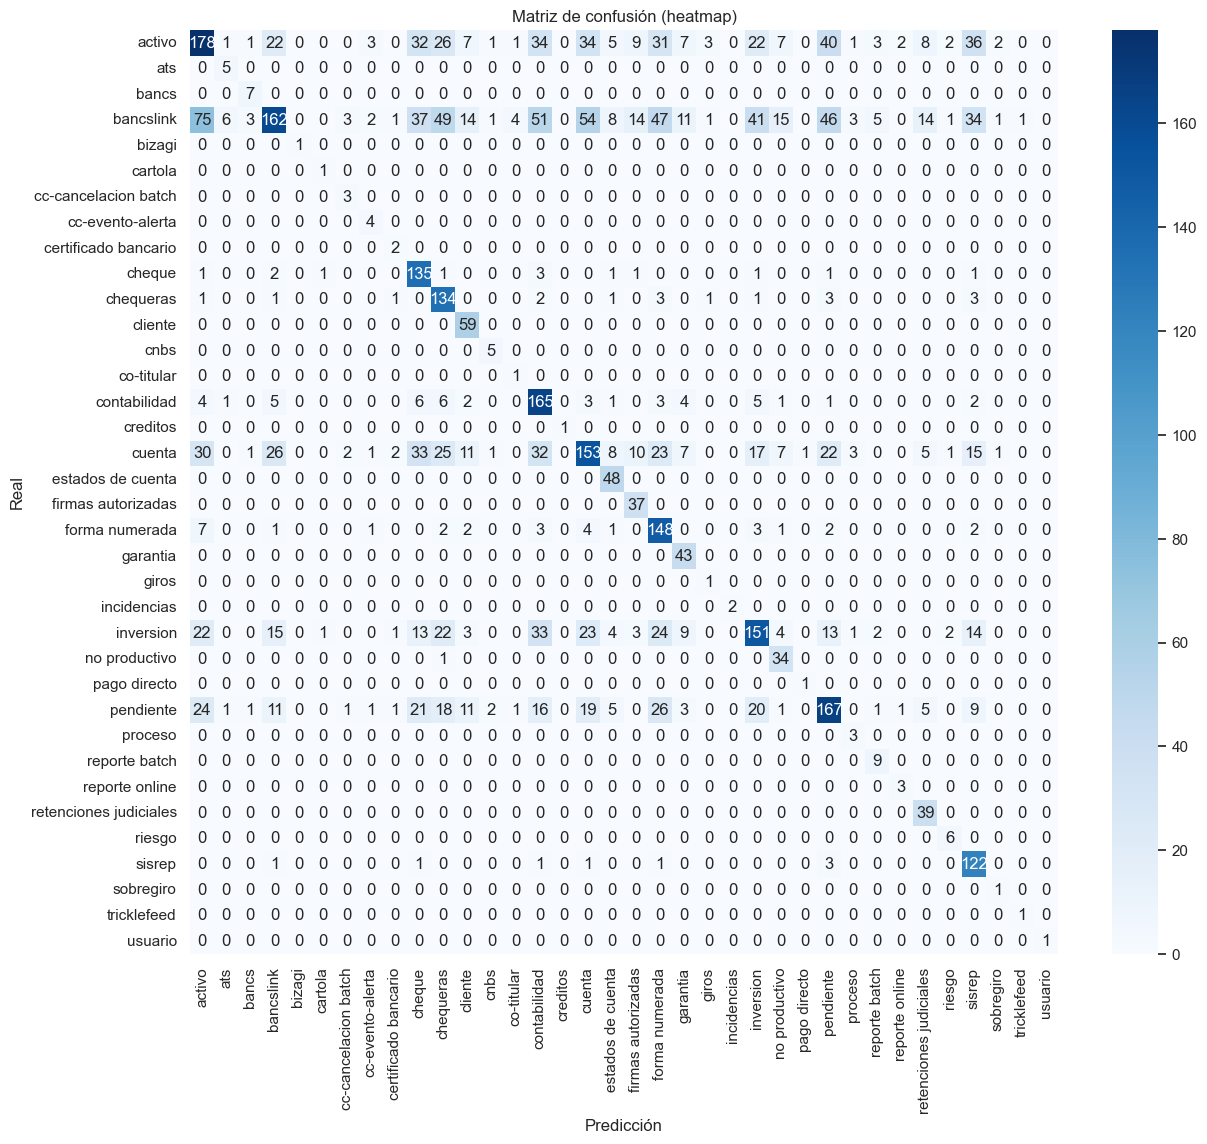

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Visualizar matriz de confusión como heatmap

labels = sorted(list(set(list(y_true) + list(y_pred))))
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión (heatmap)')
plt.show()